# BasementDrugDiscovery
## Notebook 03b -- Binding Pocket Detection and Validation

**What this notebook does:**
Runs fpocket on each prepared receptor to detect and score all druggable pockets on the protein surface. Compares detected pockets against the manually defined binding site to confirm the docking grid box is correctly placed.

**Input:** Cleaned receptor PDB files from Notebook 03

**Output:** Pocket scores and rankings, validated grid box parameters

---

### Cell 1 -- Load all required tools

In [3]:
import os
import json
import subprocess
import shutil
import tkinter as tk
from tkinter import filedialog, simpledialog, messagebox
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

from Bio.PDB import PDBParser

import ipywidgets as widgets
from IPython.display import display, clear_output

def get_tk_root():
    """Create a hidden tkinter root window for dialogs."""
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)
    return root

def browse_file(title='Select file', filetypes=None):
    """Open a file browser popup and return the selected path."""
    if filetypes is None:
        filetypes = [('All files', '*.*')]
    root = get_tk_root()
    path = filedialog.askopenfilename(title=title, filetypes=filetypes)
    root.destroy()
    return path

def browse_directory(title='Select folder'):
    """Open a folder browser popup and return the selected path."""
    root = get_tk_root()
    path = filedialog.askdirectory(title=title)
    root.destroy()
    return path

def ask_string(title, prompt, initial=''):
    """Open a simple text input popup."""
    root = get_tk_root()
    result = simpledialog.askstring(title=title, prompt=prompt, initialvalue=initial, parent=root)
    root.destroy()
    return result

def ask_float(title, prompt, initial=0.0):
    """Open a simple float input popup."""
    root = get_tk_root()
    result = simpledialog.askfloat(title=title, prompt=prompt, initialvalue=initial, parent=root)
    root.destroy()
    return result

# Verify fpocket
result = subprocess.run(['fpocket', '--help'], capture_output=True, text=True)
if 'fpocket' in result.stderr or 'fpocket' in result.stdout:
    print('fpocket is available and ready.')
else:
    print('fpocket not found. Please install with: conda install -c bioconda fpocket')

print('All tools loaded.')
print('File browser popups are ready.')

fpocket is available and ready.
All tools loaded.
File browser popups are ready.


### Cell 2 -- Select receptor PDB file and output folder

Click the buttons to open file browser windows. No typing required.

In [4]:
# Storage for selected paths
selected_paths = {
    'receptor': None,
    'output_dir': None,
    'target_name': None
}

status_output = widgets.Output()

btn_receptor = widgets.Button(
    description='Browse -- Select receptor PDB file',
    button_style='primary',
    layout=widgets.Layout(width='350px')
)

btn_output = widgets.Button(
    description='Browse -- Select output folder',
    button_style='primary',
    layout=widgets.Layout(width='350px')
)

btn_name = widgets.Button(
    description='Enter target name',
    button_style='info',
    layout=widgets.Layout(width='350px')
)

def select_receptor(b):
    with status_output:
        path = browse_file(
            title='Select cleaned receptor PDB file',
            filetypes=[('PDB files', '*.pdb'), ('All files', '*.*')]
        )
        if path:
            selected_paths['receptor'] = path
            size = Path(path).stat().st_size
            print(f'Receptor selected: {path}')
            print(f'File size: {size/1024:.1f} KB')
        else:
            print('No file selected.')

def select_output(b):
    with status_output:
        path = browse_directory(title='Select output folder for pocket analysis')
        if path:
            selected_paths['output_dir'] = path
            Path(path).mkdir(parents=True, exist_ok=True)
            print(f'Output folder: {path}')
        else:
            print('No folder selected.')

def enter_name(b):
    with status_output:
        name = ask_string(
            title='Target Name',
            prompt='Enter a short name for this target (used for output files):',
            initial='candida_albicans'
        )
        if name:
            selected_paths['target_name'] = name.strip().lower().replace(' ', '_')
            print(f'Target name: {selected_paths["target_name"]}')
        else:
            print('No name entered.')

btn_receptor.on_click(select_receptor)
btn_output.on_click(select_output)
btn_name.on_click(enter_name)

print('Click each button in order:')
display(btn_receptor)
display(btn_output)
display(btn_name)
display(status_output)

Click each button in order:


Button(button_style='primary', description='Browse -- Select receptor PDB file', layout=Layout(width='350px'),…

Button(button_style='primary', description='Browse -- Select output folder', layout=Layout(width='350px'), sty…

Button(button_style='info', description='Enter target name', layout=Layout(width='350px'), style=ButtonStyle()…

Output()

### Cell 3 -- Define your binding site center and radius

Click to load from docking_targets.json automatically, or enter coordinates manually via popups.

In [5]:
binding_site = {
    'center_x': 0.0,
    'center_y': 0.0,
    'center_z': 0.0,
    'radius': 15.0
}

site_output = widgets.Output()

btn_load_json = widgets.Button(
    description='Load from docking_targets.json',
    button_style='success',
    layout=widgets.Layout(width='300px')
)

btn_manual = widgets.Button(
    description='Enter coordinates manually',
    button_style='info',
    layout=widgets.Layout(width='300px')
)

def load_from_json(b):
    with site_output:
        clear_output()
        json_path = browse_file(
            title='Select docking_targets.json',
            filetypes=[('JSON files', '*.json'), ('All files', '*.*')]
        )
        if not json_path:
            print('No file selected.')
            return
        
        try:
            with open(json_path) as f:
                config = json.load(f)
            
            print(f'Available targets: {list(config.keys())}')
            
            target = selected_paths.get('target_name', '')
            if target not in config:
                target = ask_string(
                    title='Select Target',
                    prompt=f'Enter target name. Available: {list(config.keys())}',
                    initial=list(config.keys())[0] if config else ''
                )
            
            if target and target in config:
                grid = config[target]['grid_box']
                binding_site['center_x'] = grid['center_x']
                binding_site['center_y'] = grid['center_y']
                binding_site['center_z'] = grid['center_z']
                avg_size = (grid['size_x'] + grid['size_y'] + grid['size_z']) / 3
                binding_site['radius'] = round(avg_size / 2, 1)
                binding_site['json_path'] = json_path
                binding_site['target_key'] = target
                
                print(f'Loaded grid box for {target}')
                print(f'Center: ({binding_site["center_x"]}, {binding_site["center_y"]}, {binding_site["center_z"]})')
                print(f'Radius: {binding_site["radius"]} Angstroms')
            else:
                print(f'Target not found in JSON.')
        except Exception as e:
            print(f'Error: {e}')

def enter_manual(b):
    with site_output:
        clear_output()
        cx = ask_float('Center X', 'Enter binding site center X coordinate:', binding_site['center_x'])
        cy = ask_float('Center Y', 'Enter binding site center Y coordinate:', binding_site['center_y'])
        cz = ask_float('Center Z', 'Enter binding site center Z coordinate:', binding_site['center_z'])
        r = ask_float('Search Radius', 'Enter search radius in Angstroms:', binding_site['radius'])
        
        if cx is not None: binding_site['center_x'] = cx
        if cy is not None: binding_site['center_y'] = cy
        if cz is not None: binding_site['center_z'] = cz
        if r is not None: binding_site['radius'] = r
        
        print(f'Binding site set manually:')
        print(f'Center: ({binding_site["center_x"]}, {binding_site["center_y"]}, {binding_site["center_z"]})')
        print(f'Radius: {binding_site["radius"]} Angstroms')

btn_load_json.on_click(load_from_json)
btn_manual.on_click(enter_manual)

print('Choose how to define the binding site:')
display(btn_load_json)
display(btn_manual)
display(site_output)

Choose how to define the binding site:


Button(button_style='success', description='Load from docking_targets.json', layout=Layout(width='300px'), sty…

Button(button_style='info', description='Enter coordinates manually', layout=Layout(width='300px'), style=Butt…

Output()

### Cell 4 -- Run fpocket

In [6]:
def run_fpocket(receptor_pdb, output_dir, target_name):
    receptor_pdb = Path(receptor_pdb)
    output_dir = Path(output_dir)
    
    working_pdb = output_dir / f'{target_name}_receptor.pdb'
    shutil.copy(receptor_pdb, working_pdb)
    
    cmd = ['fpocket', '-f', str(working_pdb)]
    print(f'Running fpocket on {receptor_pdb.name}...')
    
    result = subprocess.run(cmd, capture_output=True, text=True, cwd=str(output_dir))
    
    fpocket_out = output_dir / f'{target_name}_receptor_out'
    
    if fpocket_out.exists():
        print(f'fpocket completed successfully.')
        print(f'Output: {fpocket_out}')
        return fpocket_out
    else:
        print(f'fpocket failed.')
        print(result.stderr[:500])
        return None


# Validate inputs before running
receptor = selected_paths.get('receptor')
output_dir = selected_paths.get('output_dir')
target_name = selected_paths.get('target_name')

if not receptor:
    print('No receptor file selected. Run Cell 2 first.')
elif not output_dir:
    print('No output folder selected. Run Cell 2 first.')
elif not target_name:
    print('No target name entered. Run Cell 2 first.')
else:
    print(f'Receptor: {receptor}')
    print(f'Target name: {target_name}')
    print(f'Output: {output_dir}')
    print()
    fpocket_output_dir = run_fpocket(receptor, output_dir, target_name)
    print(f'\nfpocket output directory: {fpocket_output_dir}')

Receptor: /home/sardism/BasementDrugDiscovery/data/structures/candida_albicans_sc5314_receptor.pdbqt
Target name: calbicans_pockets
Output: /home/sardism/BasementDrugDiscovery/data/structures

Running fpocket on candida_albicans_sc5314_receptor.pdbqt...
fpocket completed successfully.
Output: /home/sardism/BasementDrugDiscovery/data/structures/calbicans_pockets_receptor_out

fpocket output directory: /home/sardism/BasementDrugDiscovery/data/structures/calbicans_pockets_receptor_out


### Cell 5 -- Parse fpocket results

In [7]:
def parse_fpocket_info(fpocket_out_dir):
    info_files = list(Path(fpocket_out_dir).glob('*_info.txt'))
    if not info_files:
        print('No info file found.')
        return None
    
    info_file = info_files[0]
    pockets = []
    current_pocket = {}
    
    with open(info_file) as f:
        for line in f:
            line = line.strip()
            if line.startswith('Pocket'):
                if current_pocket:
                    pockets.append(current_pocket)
                pocket_num = int(line.split()[1])
                current_pocket = {'pocket_number': pocket_num}
            elif 'Druggability Score' in line:
                try:
                    current_pocket['druggability_score'] = float(line.split()[-1])
                except: pass
            elif 'Volume' in line and 'Score' not in line:
                try:
                    current_pocket['volume'] = float(line.split()[-1])
                except: pass
            elif 'Number of Alpha Spheres' in line:
                try:
                    current_pocket['alpha_spheres'] = int(line.split()[-1])
                except: pass
            elif 'Hydrophobicity Score' in line:
                try:
                    current_pocket['hydrophobicity'] = float(line.split()[-1])
                except: pass
            elif 'Polarity Score' in line:
                try:
                    current_pocket['polarity'] = float(line.split()[-1])
                except: pass
    
    if current_pocket:
        pockets.append(current_pocket)
    
    df = pd.DataFrame(pockets)
    if 'druggability_score' in df.columns:
        df = df.sort_values('druggability_score', ascending=False).reset_index(drop=True)
    return df


def get_pocket_centers(fpocket_out_dir):
    pocket_dir = Path(fpocket_out_dir) / 'pockets'
    pocket_files = sorted(pocket_dir.glob('pocket*_atm.pdb'))
    centers = {}
    parser = PDBParser(QUIET=True)
    
    for pf in pocket_files:
        try:
            pocket_num = int(pf.name.replace('pocket', '').replace('_atm.pdb', ''))
            structure = parser.get_structure('p', pf)
            coords = [atom.get_coord() for atom in structure.get_atoms()]
            if coords:
                center = np.mean(coords, axis=0)
                centers[pocket_num] = {
                    'center_x': round(float(center[0]), 3),
                    'center_y': round(float(center[1]), 3),
                    'center_z': round(float(center[2]), 3)
                }
        except: pass
    return centers


if fpocket_output_dir:
    df_pockets = parse_fpocket_info(fpocket_output_dir)
    pocket_centers = get_pocket_centers(fpocket_output_dir)
    
    if df_pockets is not None and len(df_pockets) > 0:
        print(f'Detected {len(df_pockets)} pockets.')
        print(f'\nTop 10 pockets by druggability score:')
        display(df_pockets.head(10))
    else:
        print('No pockets detected.')
else:
    print('fpocket output not available. Run Cell 4 first.')

Detected 34 pockets.

Top 10 pockets by druggability score:


,pocket_number,druggability_score,alpha_spheres,volume
0,5,0.980,143,4.429
1,33,0.011,25,4.818
2,28,0.011,71,4.217
3,10,0.010,40,3.556
4,21,0.008,38,3.333
5,1,0.003,43,3.562
6,2,0.002,19,4.500
7,20,0.002,18,4.000
8,17,0.002,15,5.000
9,26,0.002,19,3.833


### Cell 6 -- Compare pockets against defined binding site

In [8]:
def distance_3d(p1, p2):
    return np.sqrt(sum((a - b)**2 for a, b in zip(p1, p2)))


known_center = (
    binding_site['center_x'],
    binding_site['center_y'],
    binding_site['center_z']
)
search_radius = binding_site['radius']

print(f'Binding site center: {known_center}')
print(f'Search radius: {search_radius} Angstroms')
print()

df_comparison = None

if pocket_centers and df_pockets is not None:
    distances = []
    
    for _, row in df_pockets.iterrows():
        pnum = int(row['pocket_number'])
        if pnum in pocket_centers:
            pc = pocket_centers[pnum]
            pocket_coord = (pc['center_x'], pc['center_y'], pc['center_z'])
            dist = distance_3d(known_center, pocket_coord)
            distances.append({
                'pocket_number': pnum,
                'druggability_score': row.get('druggability_score', 0),
                'volume': row.get('volume', 0),
                'center_x': pc['center_x'],
                'center_y': pc['center_y'],
                'center_z': pc['center_z'],
                'distance_to_site': round(dist, 2),
                'overlaps_with_site': dist <= search_radius
            })
    
    df_comparison = pd.DataFrame(distances).sort_values(
        'druggability_score', ascending=False
    ).reset_index(drop=True)
    
    print('Pocket comparison results:')
    display(df_comparison)
    
    overlapping = df_comparison[df_comparison['overlaps_with_site']]
    print(f'\nPockets overlapping with binding site: {len(overlapping)}')
    
    if len(overlapping) > 0:
        best = overlapping.iloc[0]
        print(f'Best overlapping pocket: Pocket {int(best["pocket_number"])} '
              f'(score: {best["druggability_score"]:.3f}, '
              f'distance: {best["distance_to_site"]} A)')
        
        top = df_comparison.iloc[0]
        if top['overlaps_with_site']:
            print('\nTop ranked pocket overlaps with binding site -- grid box is correctly placed.')
        else:
            print(f'\nTop ranked pocket does not overlap with binding site.')
            print(f'Distance: {top["distance_to_site"]} Angstroms')
            print('Consider investigating the top ranked pocket.')
    else:
        print('No fpocket pockets overlap with the defined binding site.')
        print('Check coordinates or increase the search radius.')

Binding site center: (-37.836, -17.109, 25.716)
Search radius: 15.0 Angstroms

Pocket comparison results:


,pocket_number,druggability_score,volume,center_x,center_y,center_z,distance_to_site,overlaps_with_site
0,5,0.980,4.429,-38.178,-15.132,25.643,2.01,True
1,33,0.011,4.818,-33.583,0.303,38.972,22.29,False
2,28,0.011,4.217,-46.614,-26.275,16.828,15.49,False
3,10,0.010,3.556,-47.439,-22.422,22.588,11.41,True
4,21,0.008,3.333,-65.257,-14.167,37.615,30.04,False
5,1,0.003,3.562,-32.611,-14.550,10.737,16.07,False
6,2,0.002,4.500,-43.600,-5.076,15.586,16.75,False
7,20,0.002,4.000,-42.421,-17.464,23.799,4.98,True
8,17,0.002,5.000,-14.037,-29.046,38.167,29.39,False
9,26,0.002,3.833,-45.778,-30.597,28.988,15.99,False



Pockets overlapping with binding site: 5
Best overlapping pocket: Pocket 5 (score: 0.980, distance: 2.01 A)

Top ranked pocket overlaps with binding site -- grid box is correctly placed.


### Cell 7 -- Plot pocket analysis

Figure saved: /home/sardism/BasementDrugDiscovery/data/structures/calbicans_pockets_pocket_analysis.png


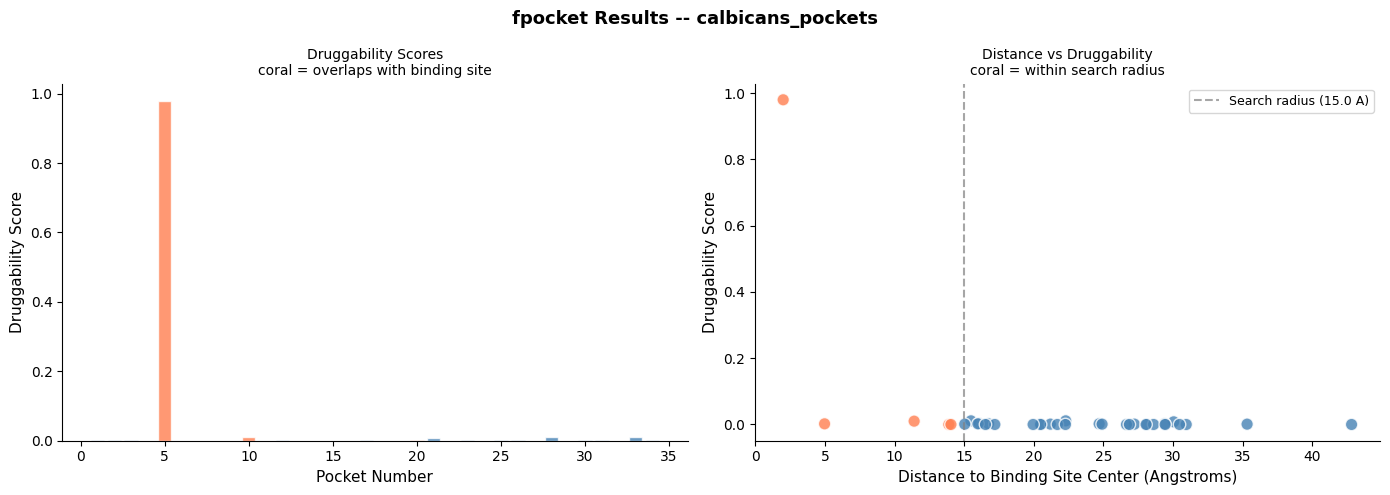

In [9]:
if df_comparison is not None and len(df_comparison) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'fpocket Results -- {target_name}', fontsize=13, fontweight='bold')
    
    colors = ['coral' if o else 'steelblue' for o in df_comparison['overlaps_with_site']]
    
    axes[0].bar(
        df_comparison['pocket_number'].astype(int),
        df_comparison['druggability_score'],
        color=colors, alpha=0.8, edgecolor='white'
    )
    axes[0].set_xlabel('Pocket Number', fontsize=11)
    axes[0].set_ylabel('Druggability Score', fontsize=11)
    axes[0].set_title('Druggability Scores\ncoral = overlaps with binding site', fontsize=10)
    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)
    
    scatter_colors = ['coral' if o else 'steelblue' for o in df_comparison['overlaps_with_site']]
    axes[1].scatter(
        df_comparison['distance_to_site'],
        df_comparison['druggability_score'],
        c=scatter_colors, s=80, alpha=0.8, edgecolors='white'
    )
    axes[1].axvline(x=search_radius, color='gray', linestyle='--',
                    alpha=0.7, label=f'Search radius ({search_radius} A)')
    axes[1].set_xlabel('Distance to Binding Site Center (Angstroms)', fontsize=11)
    axes[1].set_ylabel('Druggability Score', fontsize=11)
    axes[1].set_title('Distance vs Druggability\ncoral = within search radius', fontsize=10)
    axes[1].legend(fontsize=9)
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)
    
    plt.tight_layout()
    
    fig_path = Path(output_dir) / f'{target_name}_pocket_analysis.png'
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    print(f'Figure saved: {fig_path}')
    plt.show()
else:
    print('No comparison data. Run Cells 4 through 6 first.')

### Cell 8 -- Refine binding site if needed

If fpocket found a better pocket click the button to enter new coordinates. This updates docking_targets.json. Skip this cell if the original coordinates are confirmed correct.

In [ ]:
refine_output = widgets.Output()

btn_refine = widgets.Button(
    description='Enter new binding site coordinates',
    button_style='warning',
    layout=widgets.Layout(width='350px')
)

btn_skip = widgets.Button(
    description='Skip -- original coordinates confirmed',
    button_style='success',
    layout=widgets.Layout(width='350px')
)

def refine_site(b):
    with refine_output:
        clear_output()
        cx = ask_float('New Center X', 'Enter new binding site center X:', binding_site['center_x'])
        cy = ask_float('New Center Y', 'Enter new binding site center Y:', binding_site['center_y'])
        cz = ask_float('New Center Z', 'Enter new binding site center Z:', binding_site['center_z'])
        size = ask_float('Box Size', 'Enter docking box size in Angstroms (same for X Y Z):', binding_site['radius'] * 2)
        
        if None in (cx, cy, cz, size):
            print('Cancelled.')
            return
        
        json_path = binding_site.get('json_path')
        target_key = binding_site.get('target_key')
        
        if not json_path:
            json_path = browse_file(
                title='Select docking_targets.json to update',
                filetypes=[('JSON files', '*.json')]
            )
        
        if not target_key:
            target_key = target_name
        
        try:
            with open(json_path) as f:
                config = json.load(f)
            
            if target_key in config:
                config[target_key]['grid_box'] = {
                    'center_x': cx,
                    'center_y': cy,
                    'center_z': cz,
                    'size_x': size,
                    'size_y': size,
                    'size_z': size,
                    'padding_used': 'manual_refined'
                }
                with open(json_path, 'w') as f:
                    json.dump(config, f, indent=2)
                print(f'Updated {target_key} in docking_targets.json')
                print(f'New center: ({cx}, {cy}, {cz})')
                print(f'New box size: {size} Angstroms')
            else:
                print(f'Target {target_key} not found in JSON.')
        except Exception as e:
            print(f'Error: {e}')

def skip_refine(b):
    with refine_output:
        clear_output()
        print('Original binding site coordinates confirmed. No changes made.')
        print('Ready to proceed to Notebook 04 for docking.')

btn_refine.on_click(refine_site)
btn_skip.on_click(skip_refine)

print('Do you want to refine the binding site based on fpocket results?')
display(btn_refine)
display(btn_skip)
display(refine_output)

### Cell 9 -- Save pocket analysis summary

In [10]:
if df_comparison is not None and len(df_comparison) > 0:
    summary_path = Path(output_dir) / f'{target_name}_pocket_summary.csv'
    df_comparison.to_csv(summary_path, index=False)
    print(f'Pocket summary saved: {summary_path}')
    
    print(f'\nFinal summary for {target_name}:')
    print(f'  Total pockets detected: {len(df_comparison)}')
    print(f'  Top druggability score: {df_comparison["druggability_score"].max():.3f}')
    print(f'  Pockets overlapping binding site: {df_comparison["overlaps_with_site"].sum()}')
    
    overlapping = df_comparison[df_comparison['overlaps_with_site']]
    if len(overlapping) > 0:
        best = overlapping.iloc[0]
        top = df_comparison.iloc[0]
        if int(best['pocket_number']) == int(top['pocket_number']):
            print('  Validation: CONFIRMED -- top ranked pocket matches binding site')
        else:
            print('  Validation: PARTIAL -- binding site overlaps a pocket but not the top ranked one')
    else:
        print('  Validation: NOT CONFIRMED -- no fpocket pockets overlap with binding site')
else:
    print('No data available. Run Cells 4 through 6 first.')

Pocket summary saved: /home/sardism/BasementDrugDiscovery/data/structures/calbicans_pockets_pocket_summary.csv

Final summary for calbicans_pockets:
  Total pockets detected: 34
  Top druggability score: 0.980
  Pockets overlapping binding site: 5
  Validation: CONFIRMED -- top ranked pocket matches binding site


---
## What comes next

Run this notebook once per receptor. Change the receptor file and target name in Cell 2 each time.

Once all binding sites are validated, Notebook 04 runs AutoDock Vina -- 2,864 ligands against three targets.

**GitHub:** https://github.com/sardism/BasementDrugDiscovery

**Note:** All results are computational predictions requiring experimental validation.